In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')
from scipy.stats import skew, kurtosis,ttest_ind
import scipy.stats as stats



In [13]:
conn = sqlite3.connect("inventory.db")
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
display(df.head())

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,961067.03,0.188374,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,575664.37,0.119455,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,652182.63,0.143712,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,589500.07,0.131703,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,693281.71,0.164164,0.983556,1.396897


In [14]:
df.describe()

,VendorNumber,Brand,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
count,10692.000000,10692.000000,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,1.069200e+04,10692.000000,10692.000000,10692.000000,10692.000000,1.069200e+04,10692.000000,10692.000000
mean,10650.649458,18039.228769,24.385303,35.643671,847.360550,3140.886831,3.010669e+04,3077.482136,4.223907e+04,18793.783627,1774.226259,61433.763214,-51075.608425,-inf,1.706793,2.504390
std,18753.519148,12662.187074,109.269375,148.246016,664.309212,11095.086769,1.230678e+05,10952.851391,1.676553e+05,44952.773386,10975.582240,60938.458032,67282.339560,NaN,6.020460,8.459067
min,2.000000,58.000000,0.360000,0.490000,50.000000,1.000000,7.100000e-01,0.000000,0.000000e+00,0.000000,0.000000,0.090000,-272403.270000,-inf,0.000000,0.000000
25%,3951.000000,5793.500000,6.840000,10.990000,750.000000,36.000000,4.534575e+02,33.000000,7.292200e+02,289.710000,4.800000,14069.870000,-75892.235000,-4.157226e+01,0.807229,1.153729
50%,7153.000000,18761.500000,10.455000,15.990000,750.000000,262.000000,3.655465e+03,261.000000,5.298045e+03,2857.800000,46.570000,50293.620000,-32035.425000,-5.631826e+00,0.981529,1.436894
75%,9552.000000,25514.250000,19.482500,28.990000,750.000000,1975.750000,2.073825e+04,1929.250000,2.839692e+04,16059.562500,418.650000,79528.990000,-7989.535000,-7.840347e-01,1.039342,1.665449
max,201359.000000,90631.000000,5681.810000,7499.990000,20000.000000,337660.000000,3.811252e+06,334939.000000,5.101920e+06,672819.310000,368242.800000,257032.070000,961067.030000,9.875679e-01,274.500000,352.928571


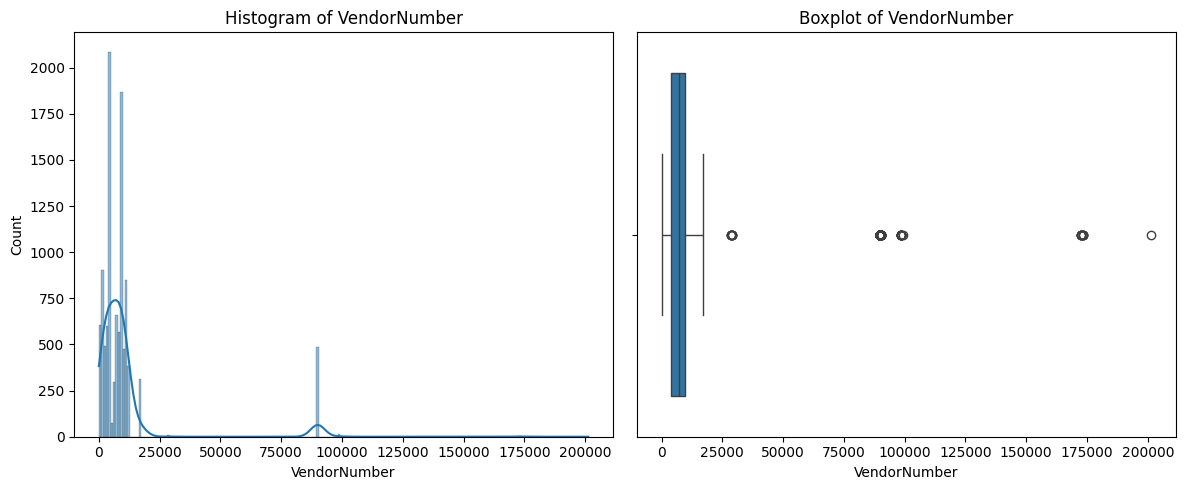

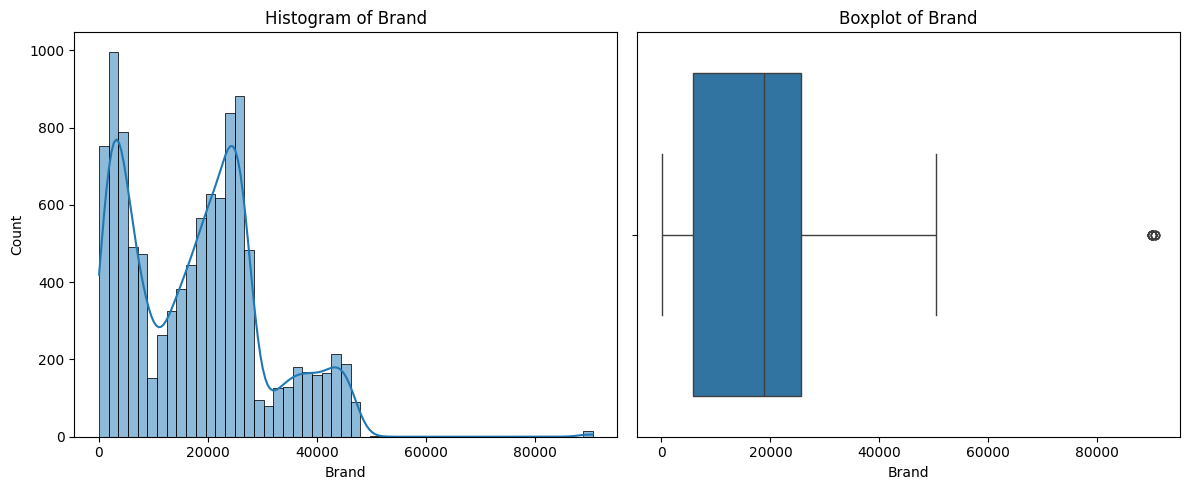

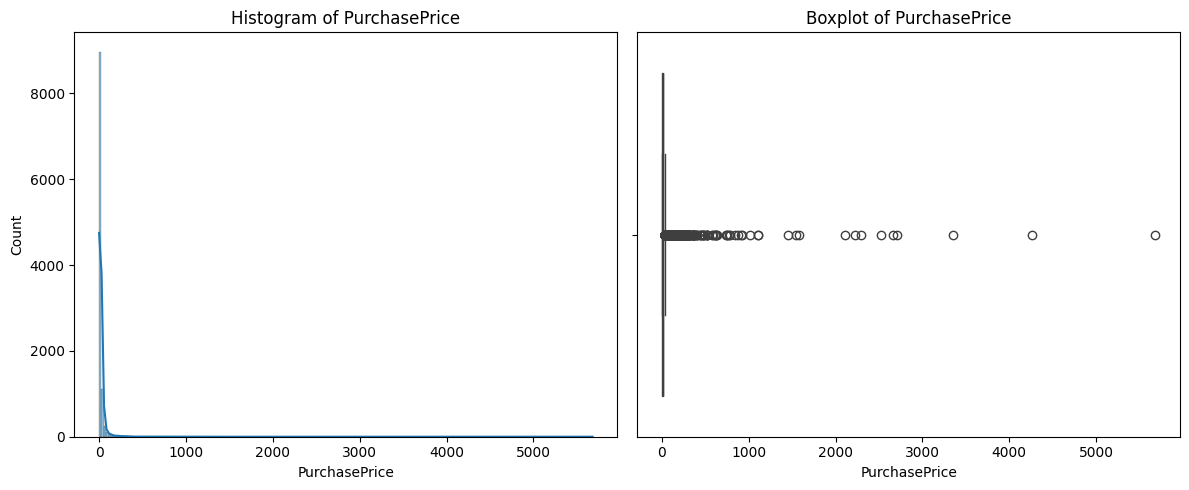

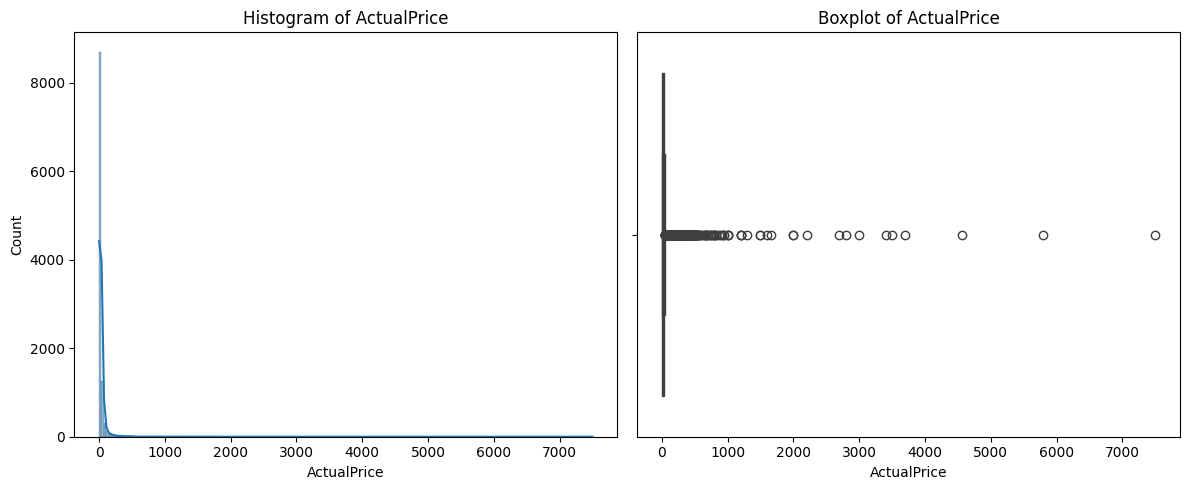

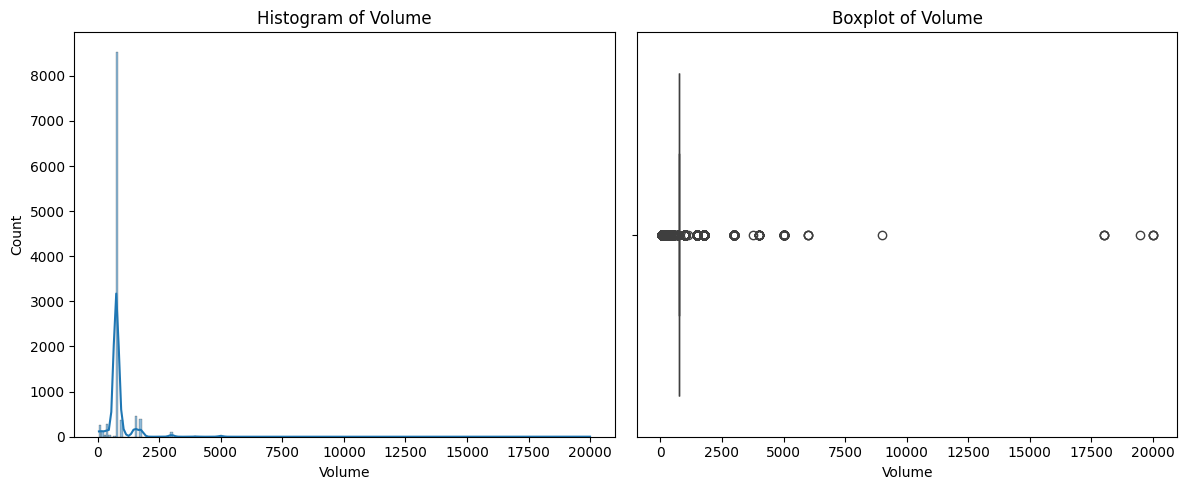

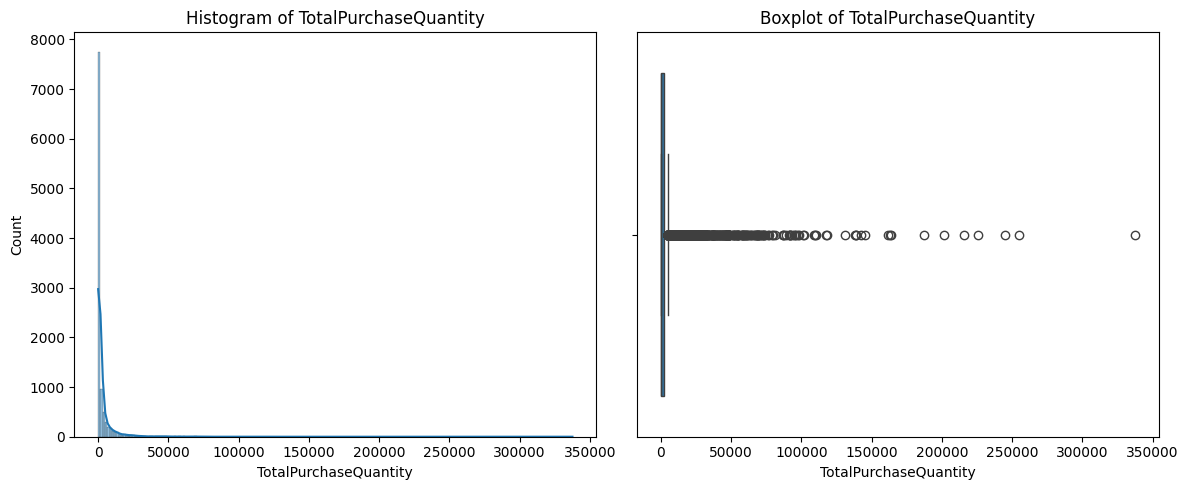

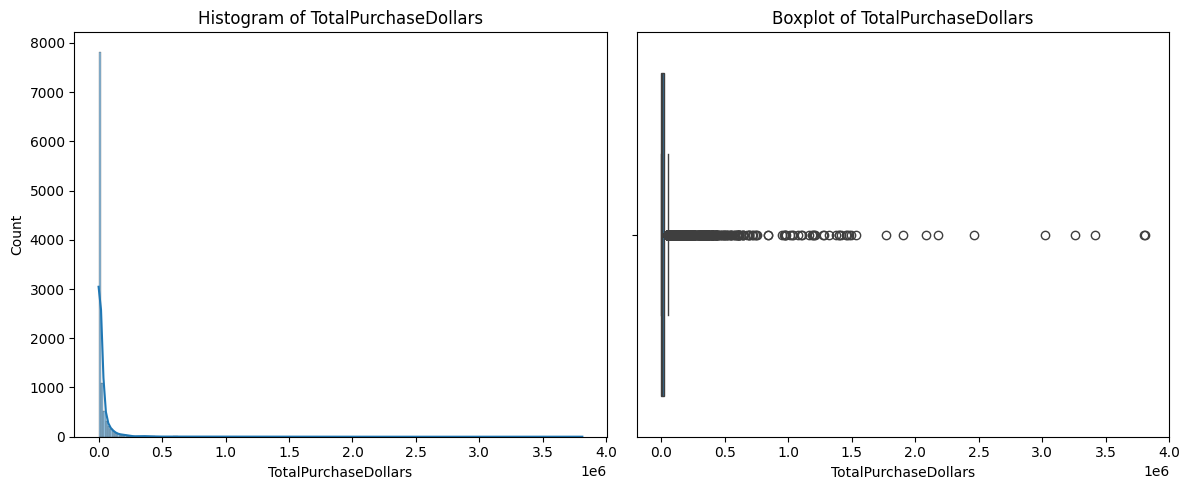

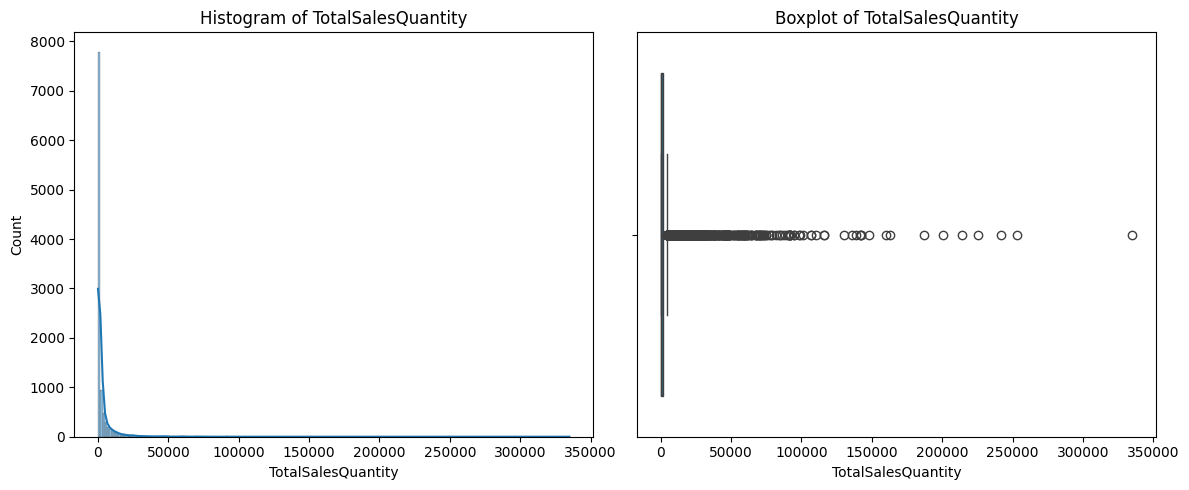

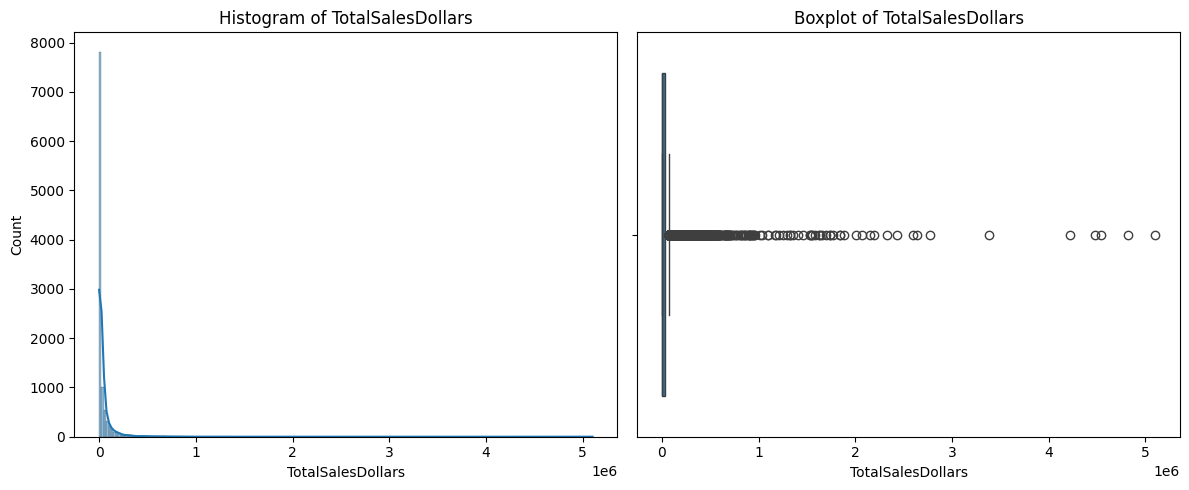

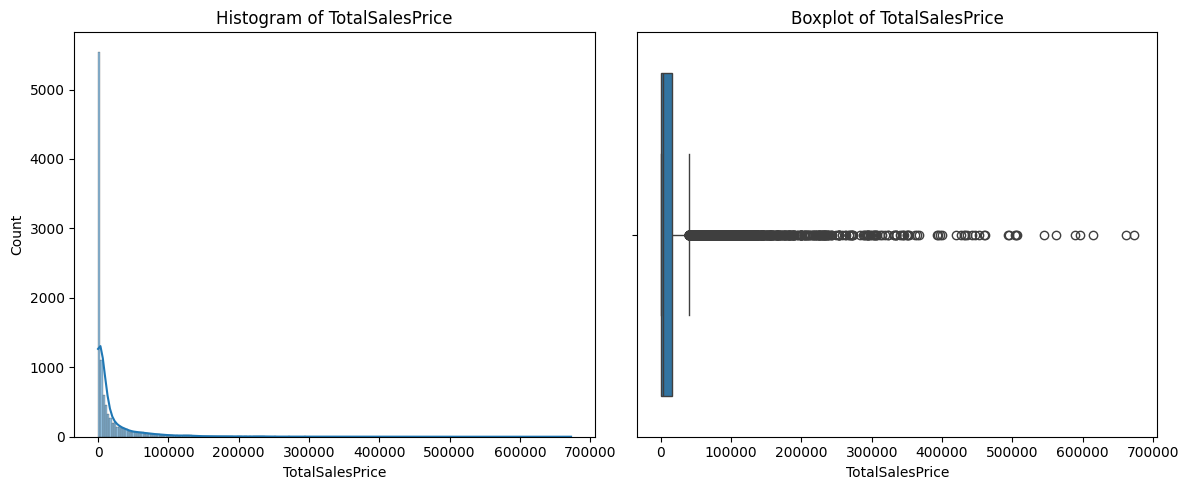

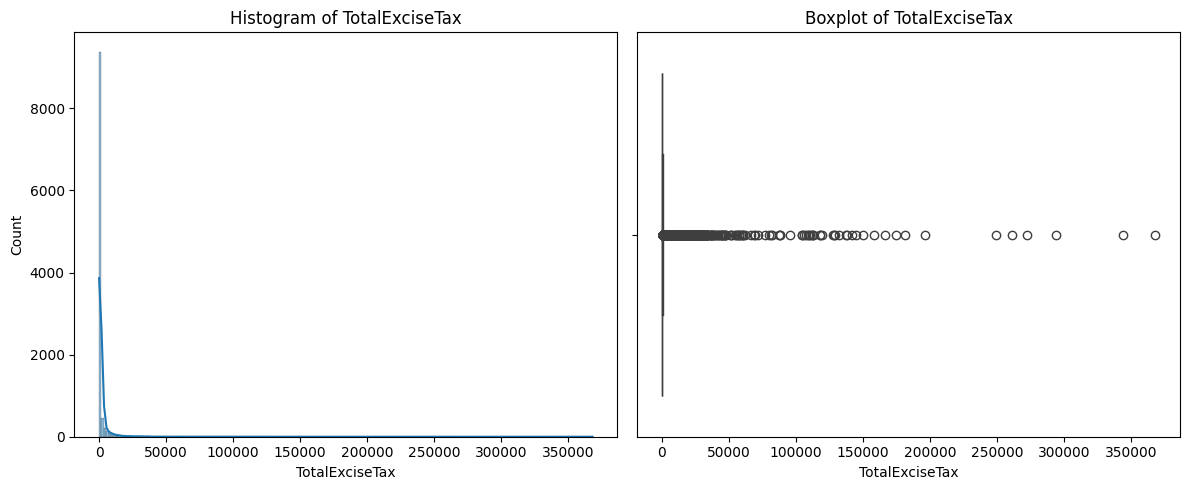

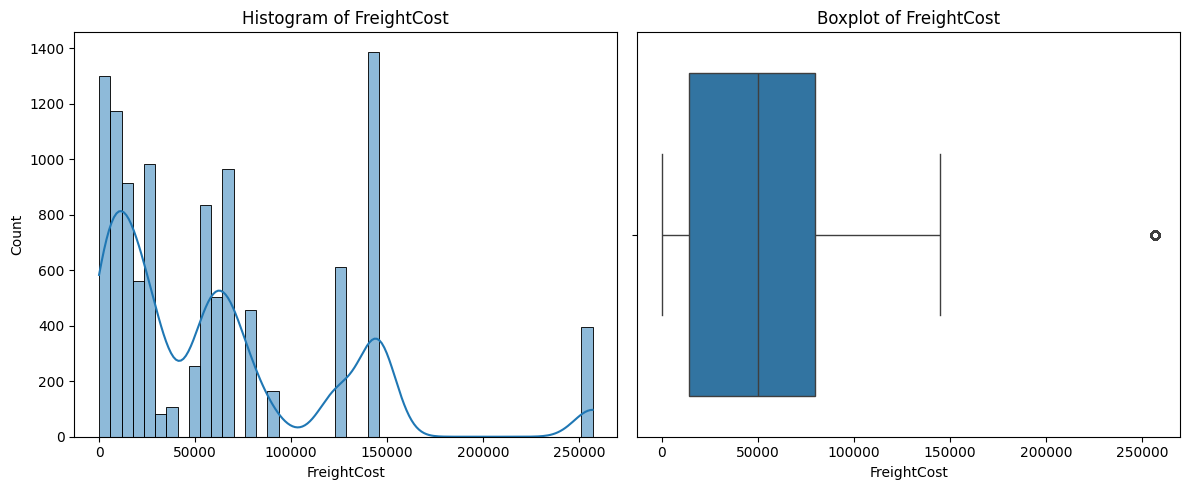

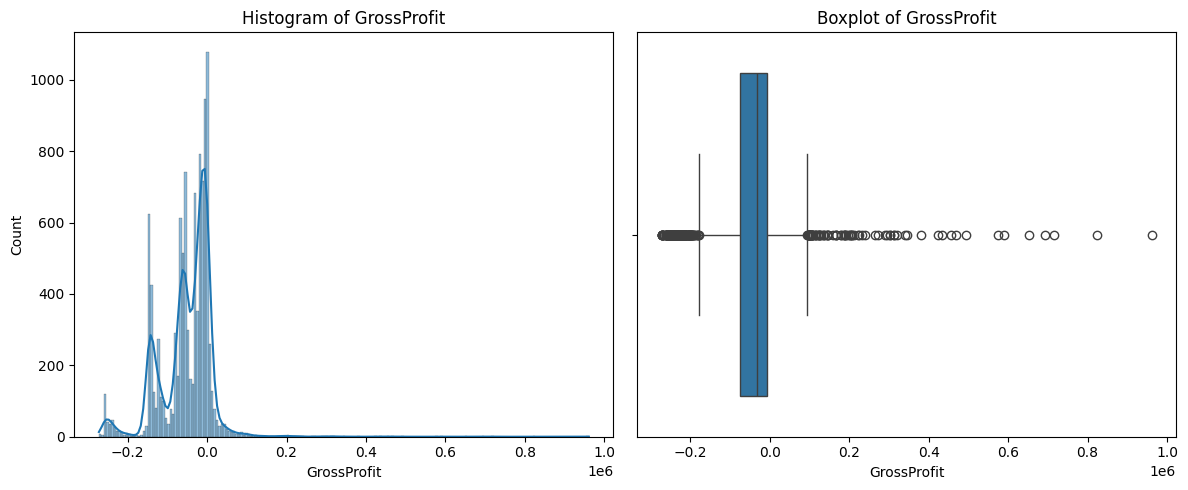

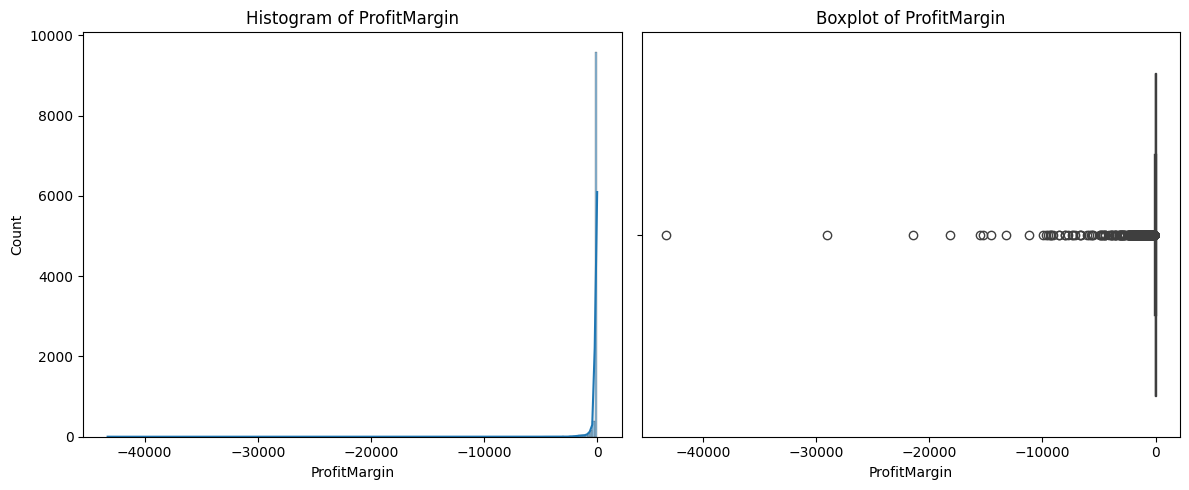

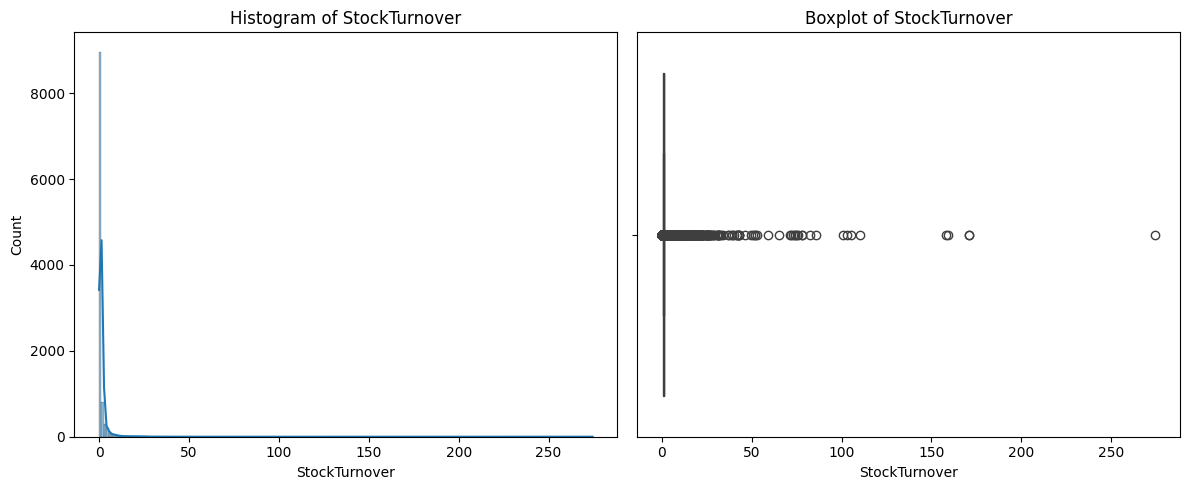

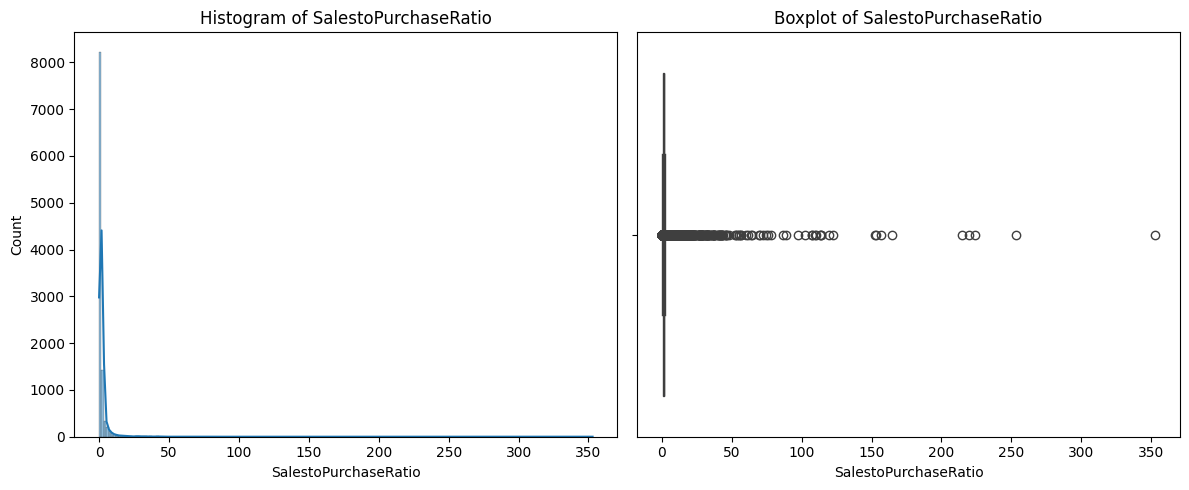

In [15]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

In [17]:
df = pd.read_sql_query("""
SELECT *
FROM vendor_sales_summary
WHERE GrossProfit > 0
AND ProfitMargin > 0
AND TotalSalesQuantity > 0
""", conn)
df


,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalestoPurchaseRatio
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,142049.0,5101919.51,672819.31,260999.20,68601.68,961067.03,0.188374,0.979108,1.338647
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,160247.0,4819073.49,561512.37,294438.66,144929.24,575664.37,0.119455,0.976890,1.266830
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,187140.0,4538120.60,461140.15,343854.07,123780.22,652182.63,0.143712,0.998575,1.327594
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,200412.0,4475972.88,420050.01,368242.80,257032.07,589500.07,0.131703,0.993703,1.372493
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,135838.0,4223107.62,545778.28,249587.83,257032.07,693281.71,0.164164,0.983556,1.396897
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1236,8663,STAR INDUSTRIES INC.,3991,Georgi Watermelon Vodka,7.87,9.99,1000.0,3,23.61,10.0,99.90,59.94,10.50,12.44,53.35,0.534034,3.333333,4.231258
1237,7749,R.P.IMPORTS INC,19612,Ch Petit Bocq Cru Borgeos 10,21.19,31.99,750.0,1,21.19,10.0,319.90,191.94,1.11,91.50,206.10,0.644264,10.000000,15.096744
1238,201359,FLAVOR ESSENCE INC,90609,Flavor Essence Variety 5 Pak,17.00,24.99,162.5,1,17.00,59.0,1474.41,1324.47,1.24,0.09,1456.08,0.987568,59.000000,86.730000
1239,1650,Circa Wines,22225,Gifft Chardonnay,8.05,13.99,750.0,2,16.10,20.0,279.80,153.89,2.22,211.97,49.51,0.176948,10.000000,17.378882


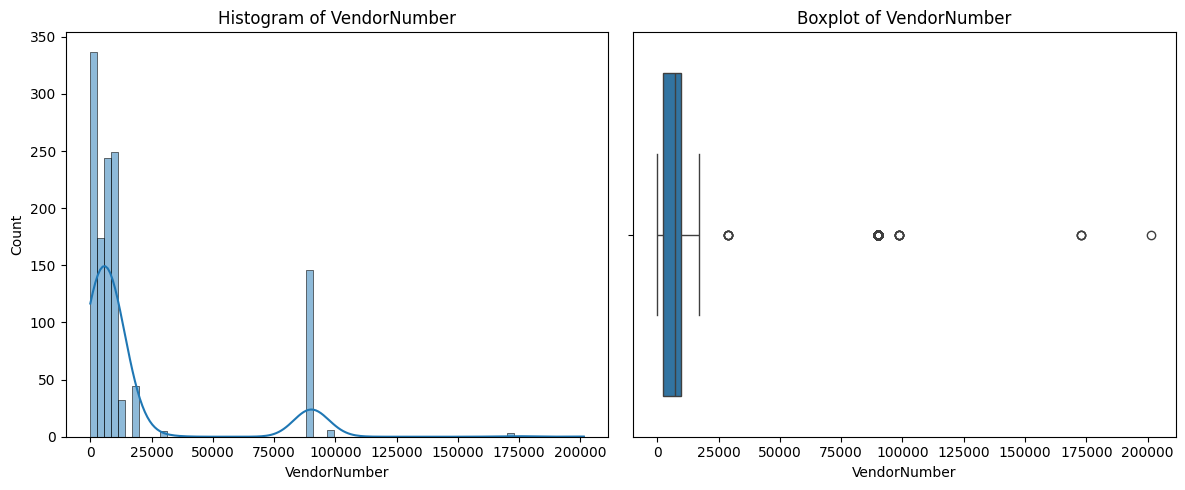

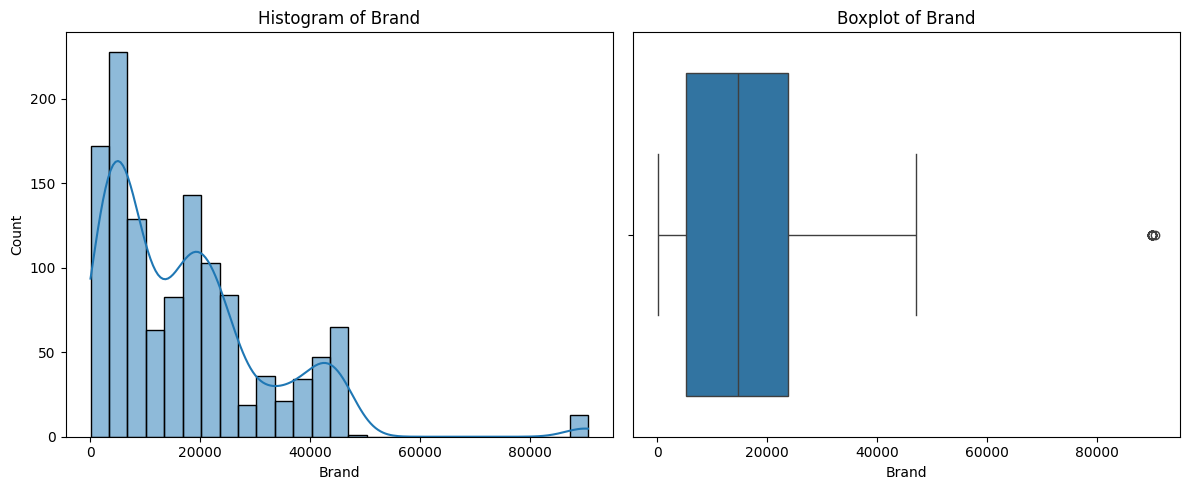

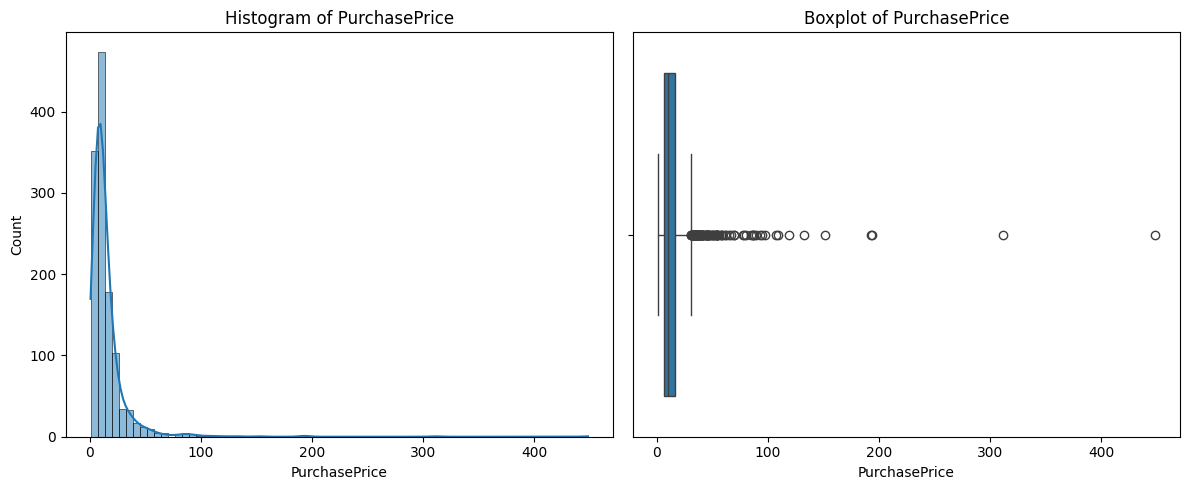

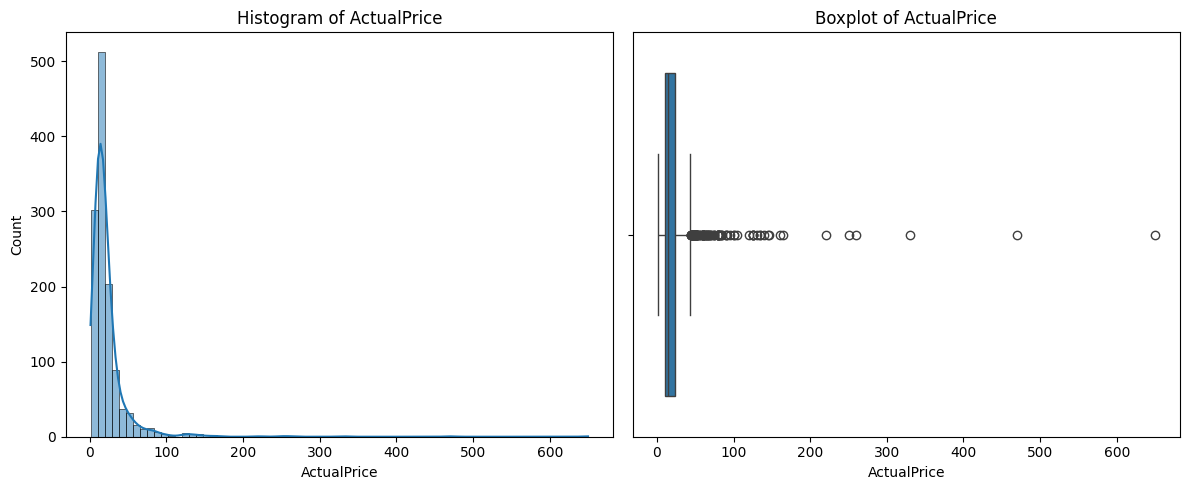

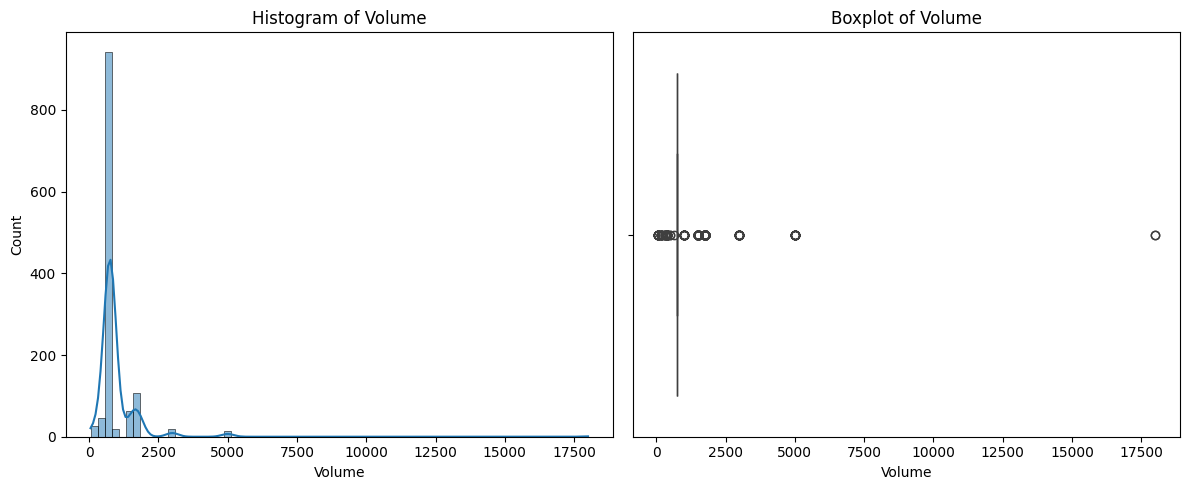

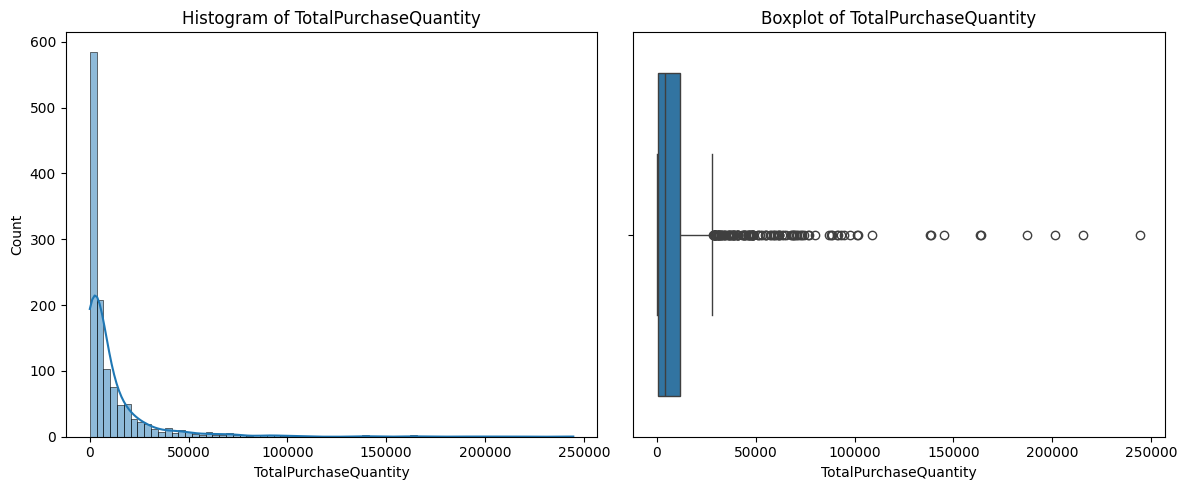

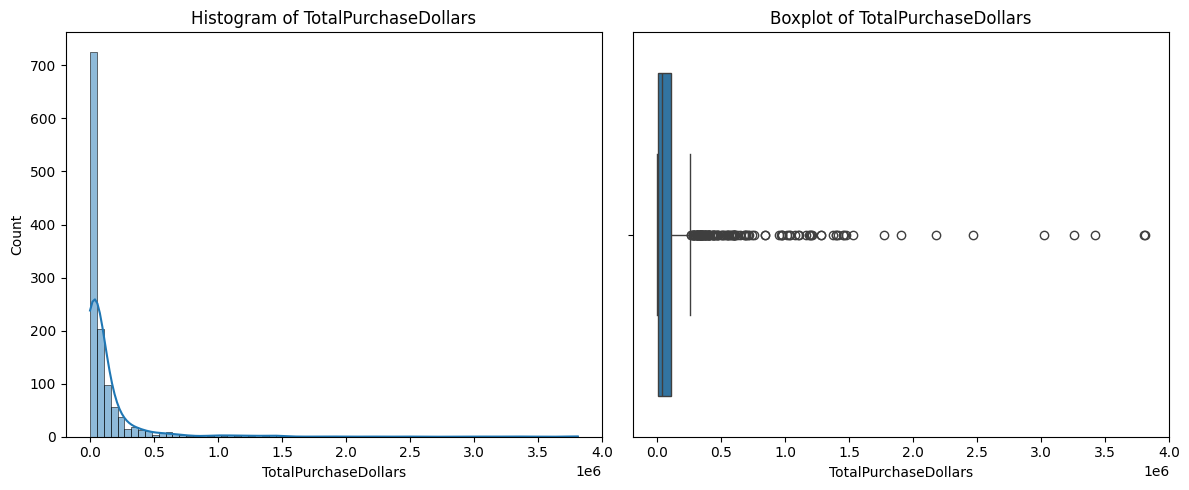

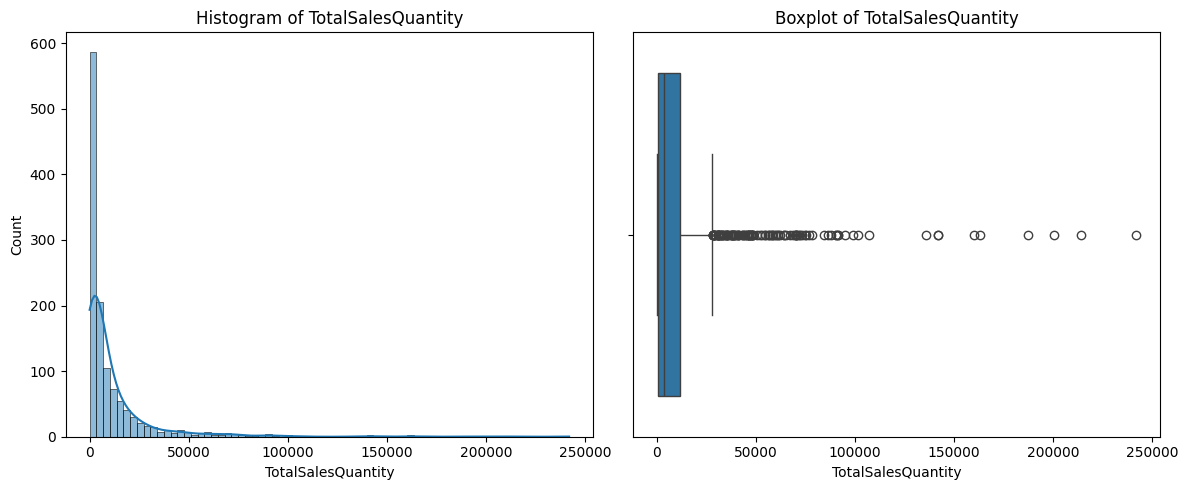

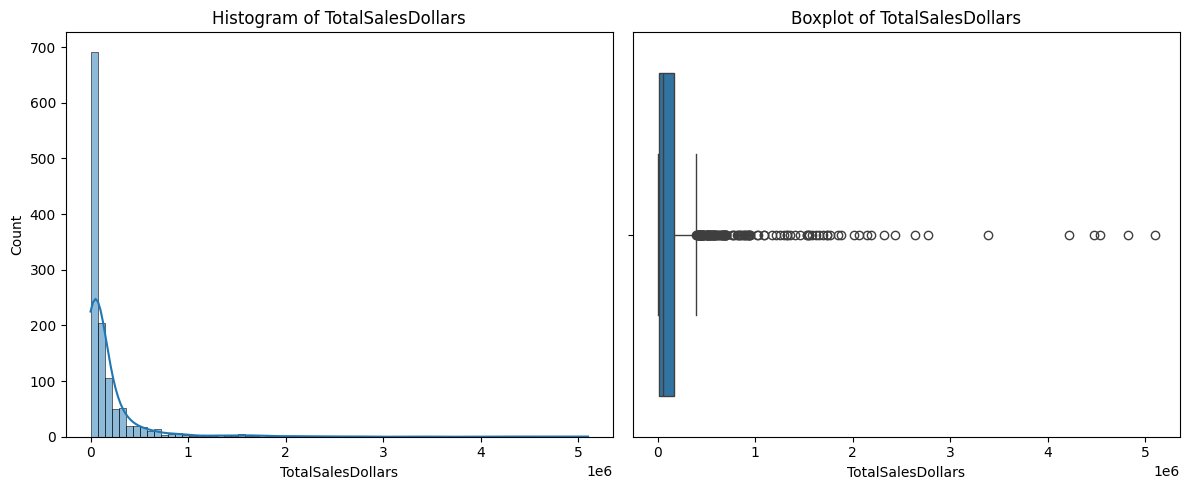

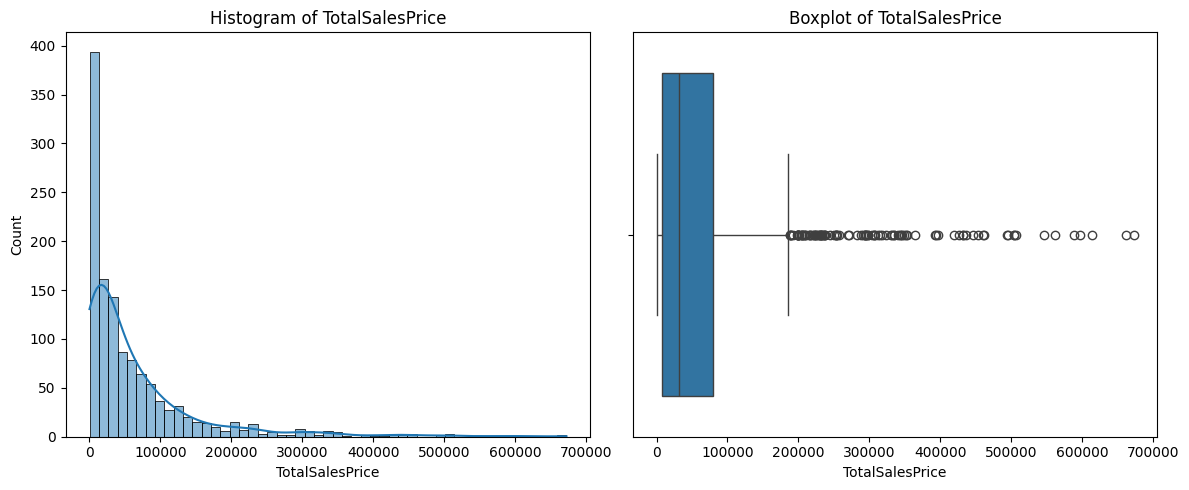

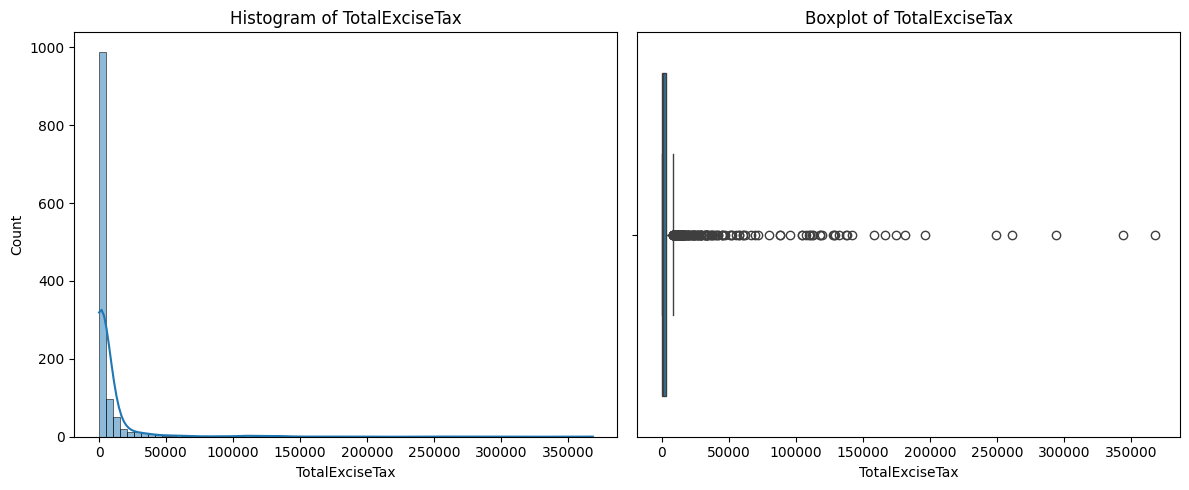

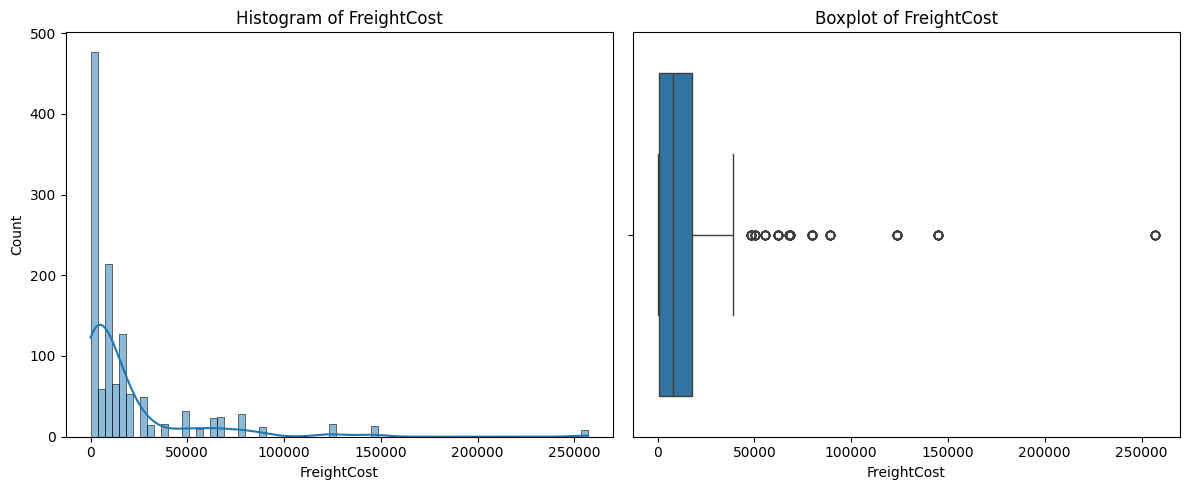

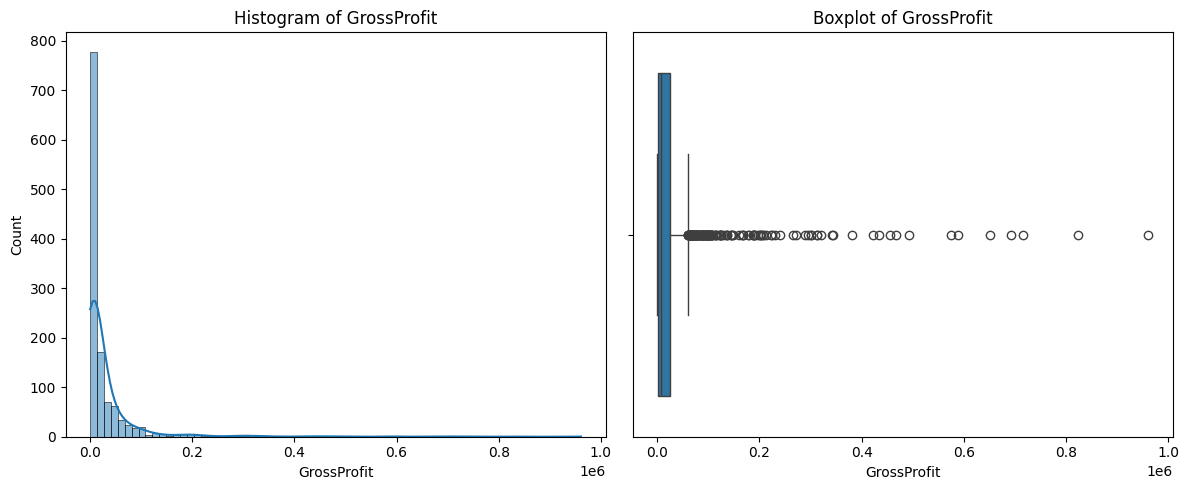

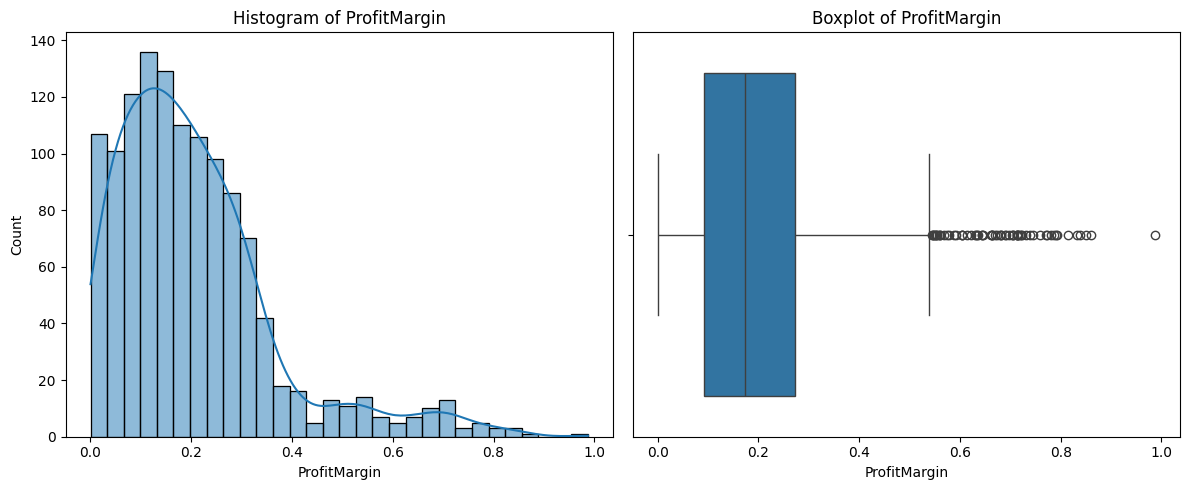

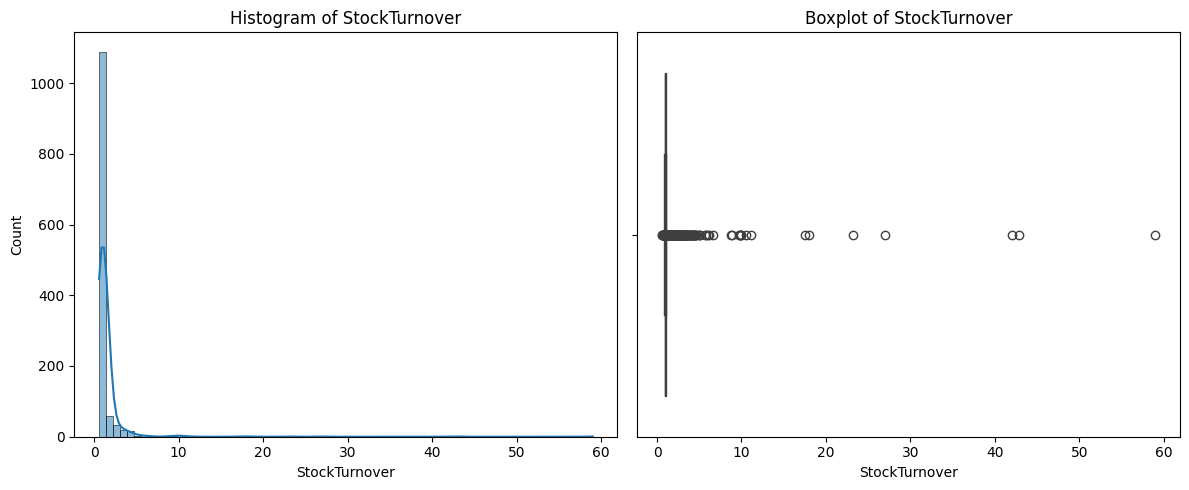

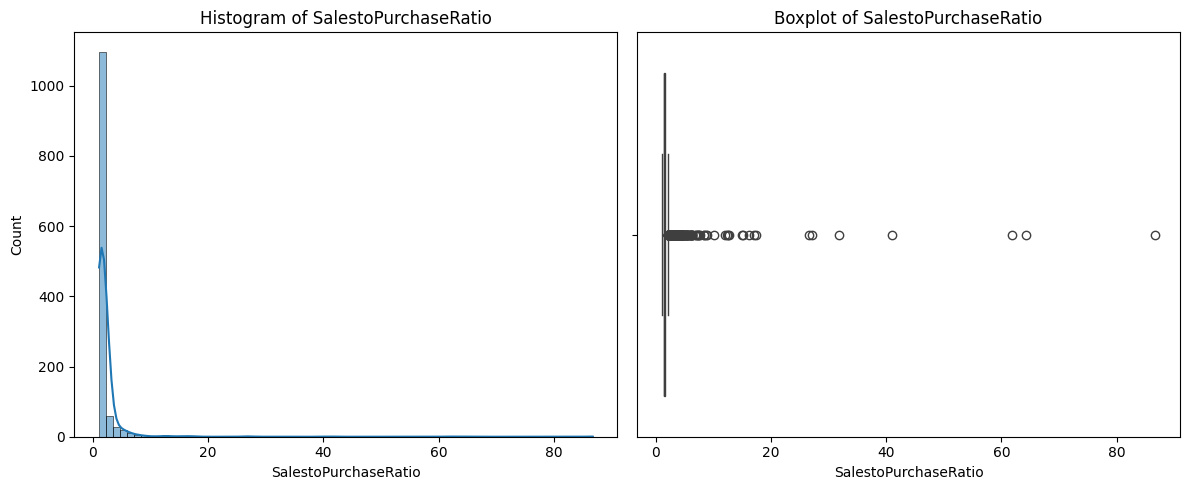

In [18]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    
    plt.tight_layout()
    plt.show()

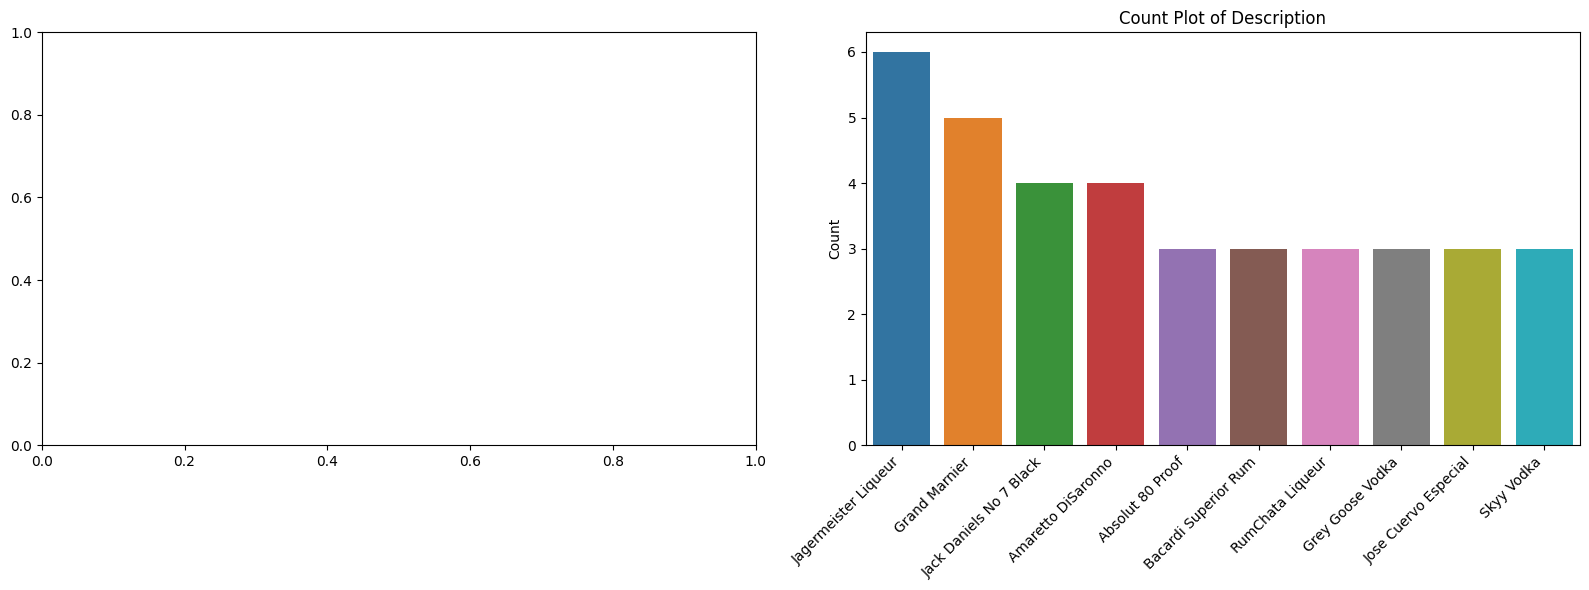

In [27]:
categorical_cols = ['VendorName', 'Description']

plt.figure(figsize=(16, 6))
for i, col in enumerate(categorical_cols, start=1):
    plt.subplot(1, 2, i)
order = df[col].value_counts().iloc[:10].index
sns.countplot(x=df[col], order=order, palette='tab10')
plt.title(f'Count Plot of {col}')
plt.xticks(rotation=45, ha='right')
plt.xlabel('')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

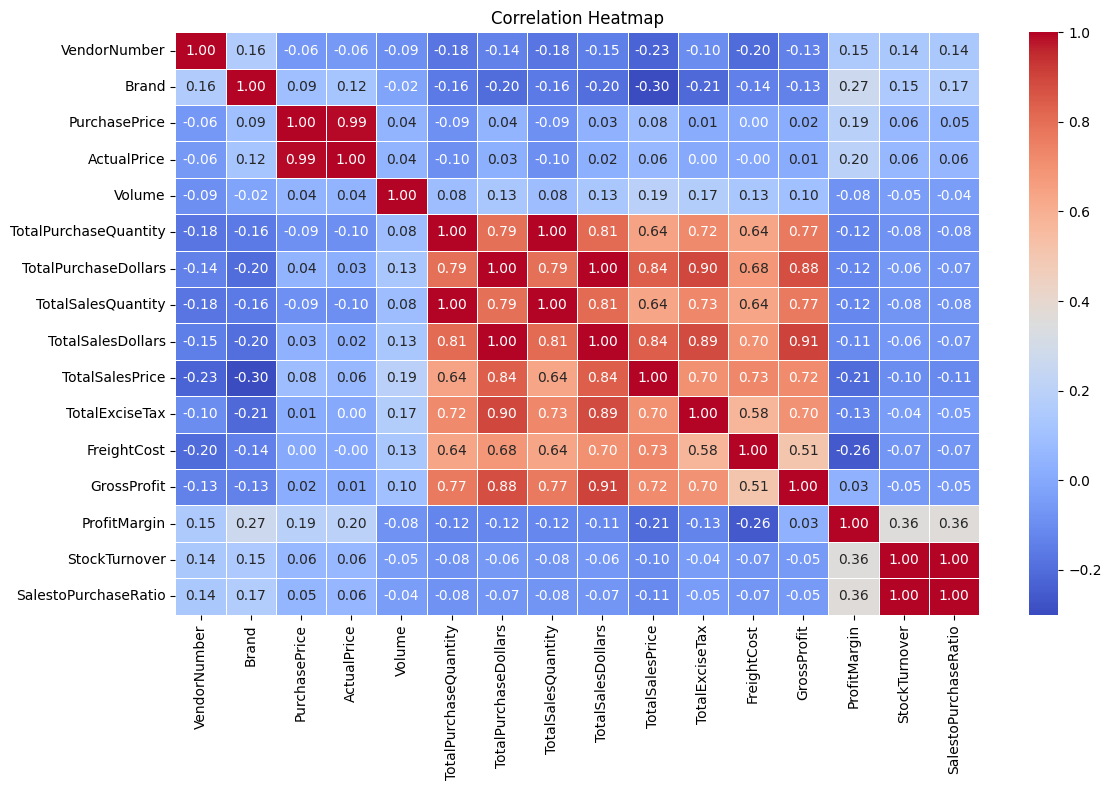

In [28]:
numerical_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
correlation_matrix,
annot=True,
fmt=".2f",
cmap="coolwarm",
linewidths=0.5,
cbar=True
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [32]:
brand_performance = df.groupby("Description").agg({
"TotalSalesDollars": "sum",
"ProfitMargin": "mean",
}).reset_index()

In [42]:
low_sales_threshold = brand_performance["TotalSalesDollars"].quantile(0.15)
high_margin_threshold = brand_performance["ProfitMargin"].quantile(0.85)


In [43]:
low_sales_threshold

np.float64(4867.48)

In [44]:

high_margin_threshold

np.float64(0.32802275276487547)

In [45]:
target_brands = brand_performance[
(brand_performance["TotalSalesDollars"] < low_sales_threshold) &
(brand_performance["ProfitMargin"] > high_margin_threshold)
]
print("Target Brands for Intervention:")
display(target_brands)


Target Brands for Intervention:


,Description,TotalSalesDollars,ProfitMargin
9,44* North Magic Valley Vodka,1349.40,0.416392
30,Alta Classe Mntplcno Abruzzo,327.59,0.591685
34,Anastasi Estates Messinia Rd,323.73,0.560869
45,Apimed Old Slavic Mead Light,635.40,0.330721
65,Bakon Vodka,2049.18,0.403449
...,...,...,...
1064,Tommaso Bussola Amarone Clsc,899.85,0.506873
1086,Ty Ku Coconut Nigori,4404.44,0.344800
1100,Vigna Magana Dignus,359.82,0.702629
1108,Volker Eisele Family Est Cab,949.81,0.491330


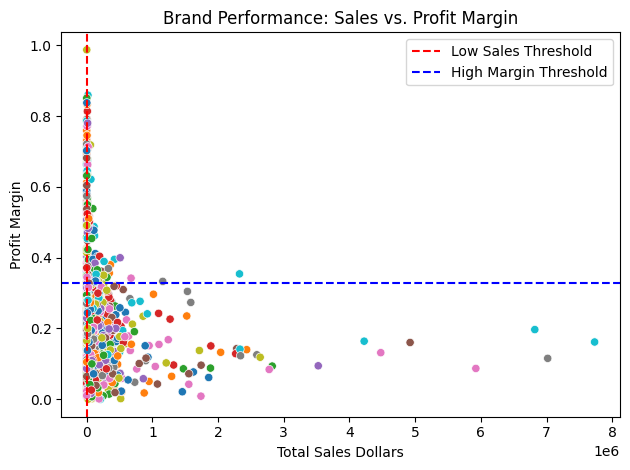

In [46]:
plt.Figure(figsize=(10, 6))
sns.scatterplot(
data=brand_performance,     
x="TotalSalesDollars",
y="ProfitMargin",
hue="Description",
palette="tab10",
legend=False
)
plt.title("Brand Performance: Sales vs. Profit Margin")
plt.xlabel("Total Sales Dollars")
plt.ylabel("Profit Margin")
plt.axvline(x=low_sales_threshold, color='red', linestyle='--', label='Low Sales Threshold')
plt.axhline(y=high_margin_threshold, color='blue', linestyle='--', label
='High Margin Threshold')
plt.legend()
plt.tight_layout()
plt.show()


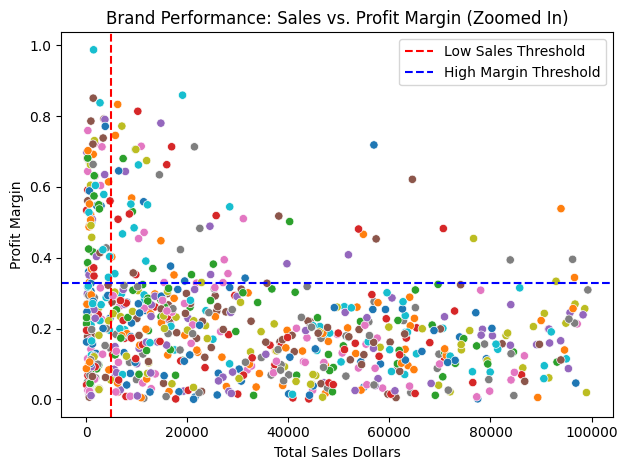

In [48]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<100000]

plt.Figure(figsize=(10, 6))
sns.scatterplot(
data=brand_performance,
x="TotalSalesDollars",
y="ProfitMargin",
hue="Description",
palette="tab10",
legend=False
)
plt.title("Brand Performance: Sales vs. Profit Margin (Zoomed In)")
plt.xlabel("Total Sales Dollars")
plt.ylabel("Profit Margin")
plt.axvline(x=low_sales_threshold, color='red', linestyle='--', label
='Low Sales Threshold')
plt.axhline(y=high_margin_threshold, color='blue', linestyle='--', label
='High Margin Threshold')
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"${value / 1_000_000:,.2f}M"
    elif value >= 1_000:
        return f"${value / 1_000:,.2f}K"
    else:
        return f"${value:,.2f}"

In [73]:
top_brands.apply(lambda x: format_dollars(x))

Description
Jack Daniels No 7 Black    $7.73M
Tito's Handmade Vodka      $7.02M
Grey Goose Vodka           $6.82M
Absolut 80 Proof           $5.92M
Jameson Irish Whiskey      $4.92M
Capt Morgan Spiced Rum     $4.48M
Ketel One Vodka            $4.22M
Baileys Irish Cream        $3.52M
Bacardi Superior Rum       $2.82M
Kahlua                     $2.78M
Name: TotalSalesDollars, dtype: object

In [78]:
top_vendors = (
    df.groupby("VendorName")["TotalSalesDollars"]
    .sum()
    .nlargest(10)
    .reset_index()
)

top_brands = (
    df.groupby("Description")["TotalSalesDollars"]
    .sum()
    .nlargest(10)
    .reset_index()
)

In [79]:
print("\nTop 10 Brands by Total Sales Dollars:")
top_brands


Top 10 Brands by Total Sales Dollars:


,Description,TotalSalesDollars
0,Jack Daniels No 7 Black,7730401.48
1,Tito's Handmade Vodka,7016605.45
2,Grey Goose Vodka,6820192.82
3,Absolut 80 Proof,5923018.88
4,Jameson Irish Whiskey,4922333.26
5,Capt Morgan Spiced Rum,4475972.88
6,Ketel One Vodka,4223107.62
7,Baileys Irish Cream,3524265.94
8,Bacardi Superior Rum,2823593.54
9,Kahlua,2777766.14


In [80]:
print("Top Vendors Columns:", top_vendors.columns)
print("Top Brands Columns:", top_brands.columns)

Top Vendors Columns: Index(['VendorName', 'TotalSalesDollars'], dtype='object')
Top Brands Columns: Index(['Description', 'TotalSalesDollars'], dtype='object')


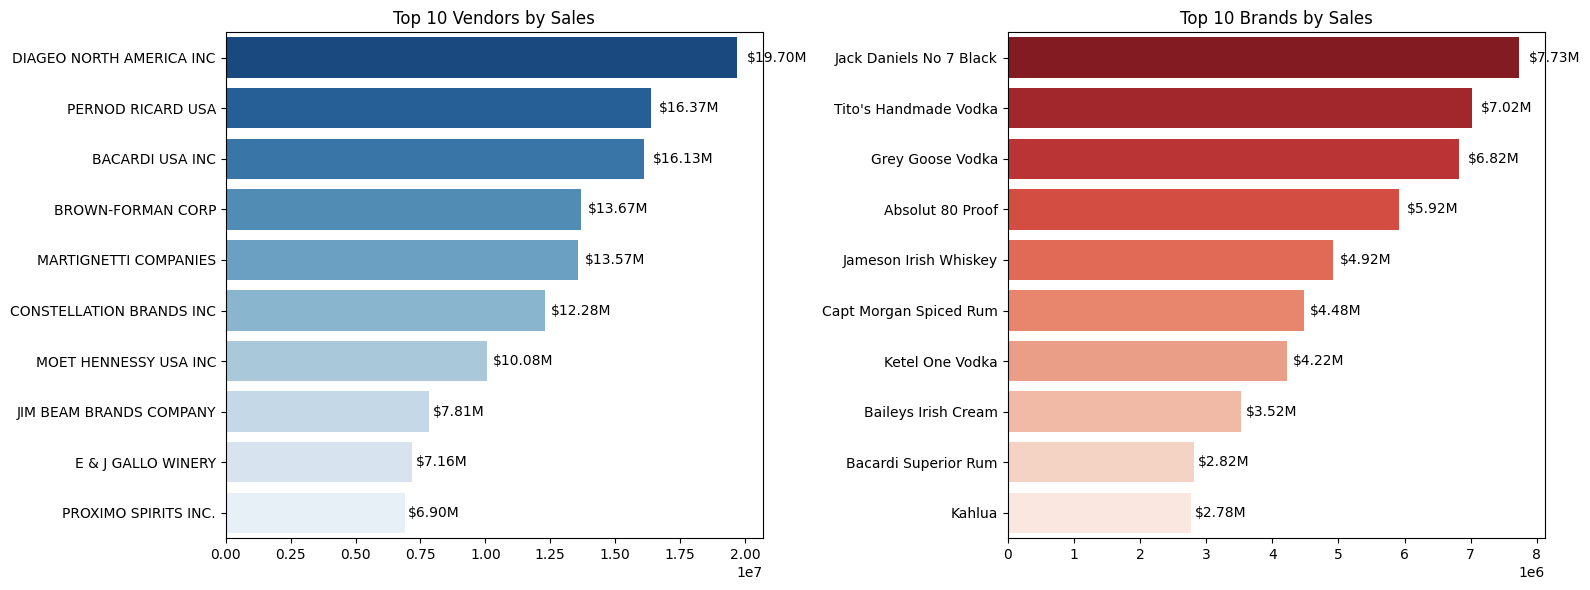

In [81]:
plt.figure(figsize=(16, 6))

ax1 = plt.subplot(1, 2, 1)
sns.barplot(
    y=top_vendors["VendorName"],
    x=top_vendors["TotalSalesDollars"],
    palette="Blues_r",
    ax=ax1
)
ax1.set_title("Top 10 Vendors by Sales")
for bar in ax1.patches:
    ax1.text(
        bar.get_width() + bar.get_width() * 0.02,
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black",
    )
ax1.set_xlabel("")
ax1.set_ylabel("")

ax2 = plt.subplot(1, 2, 2)
sns.barplot(
    y=top_brands["Description"].astype(str),
    x=top_brands["TotalSalesDollars"],
    palette="Reds_r",
    ax=ax2
)
ax2.set_title("Top 10 Brands by Sales")
for bar in ax2.patches:
    ax2.text(
        bar.get_width() + bar.get_width() * 0.02,
        bar.get_y() + bar.get_height() / 2,
        format_dollars(bar.get_width()),
        ha="left",
        va="center",
        fontsize=10,
        color="black",
    )
ax2.set_xlabel("")
ax2.set_ylabel("")

plt.tight_layout()
plt.show()

In [90]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%', ascending=False, ),2)

In [92]:
vendor_performance = df.groupby("VendorName").agg({
    "TotalPurchaseDollars": "sum",
    "TotalSalesDollars": "sum",
    "ProfitMargin": "mean"
}).reset_index()

vendor_performance["PurchaseContribution%"] = (
    vendor_performance["TotalPurchaseDollars"] /
    vendor_performance["TotalPurchaseDollars"].sum()
)

vendor_performance.head()

,VendorName,TotalPurchaseDollars,TotalSalesDollars,ProfitMargin,PurchaseContribution%
0,ALISA CARR BEVERAGES,25698.12,104470.94,0.708313,0.000165
1,ALTAMAR BRANDS LLC,11706.20,15706.81,0.130356,0.000075
2,AMERICAN SPIRITS EXCHANGE,934.08,1511.16,0.371542,0.000006
3,AMERICAN VINTAGE BEVERAGE,104435.68,139603.53,0.096619,0.000671
4,ATLANTIC IMPORTING COMPANY,41116.32,59272.75,0.538437,0.000264


KeyError: 'Purchase_Contribution%'

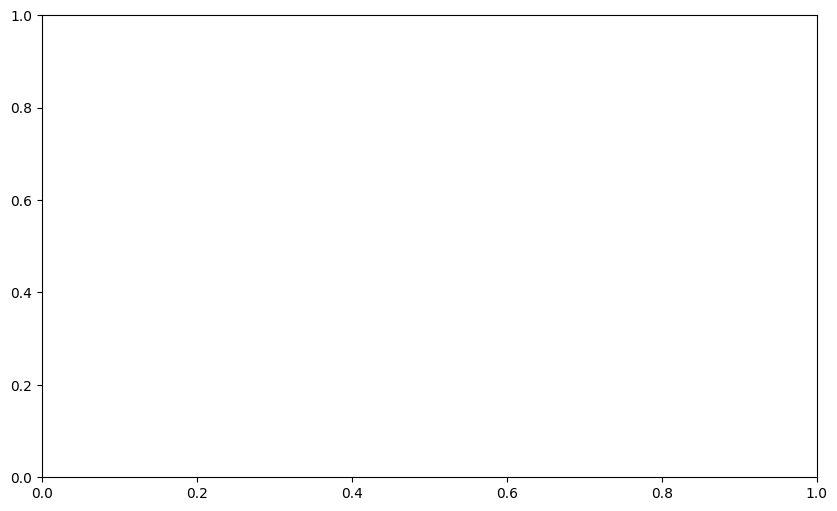

In [94]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%
sns.barplot(
    x=top_vendors['VendorName'],
    y=top_vendors['Purchase_Contribution%'],
    palette="mako",
    ax=ax1
)

for i, value in enumerate(top_vendors['Purchase_Contribution%']):
    ax1.text(i, value - 1, str(value) + '%',
             ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%
ax2 = ax1.twinx()

ax2.plot(
    top_vendors['VendorName'],
    top_vendors['Cumulative_Contribution%'],
    color='red',
    marker='o'
)

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)

ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')

ax1.set_xlabel('Vendors')

ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

ax2.legend(loc='upper right')

plt.show()